In [ ]:
## Use Case: Perform the Outlier detection for the given dataset i.e. datasetExample
## Dataset: datasetExample.csv
## Perform the following task
## 1. Load the data in the DataFrame.
## 2. Detection of Outliers

In [2]:
import pandas as pd
cars = pd.read_csv("cars.csv")
print(cars.shape)   
print(cars.head())
print(cars.info())

(398, 9)
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    in

In [3]:
cars = cars[cars['horsepower'] != '?'].copy()
cars['horsepower'] = cars['horsepower'].astype(float)
print(cars.shape) 

(392, 9)


In [4]:
def detect_outliers_iqr(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return col[(col < lower_bound) | (col > upper_bound)]

numeric_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
for col in numeric_cols:
    outliers = detect_outliers_iqr(cars[col])
    print(f"{col}: {len(outliers)} outliers")

mpg: 0 outliers
displacement: 0 outliers
horsepower: 10 outliers
weight: 0 outliers
acceleration: 11 outliers


In [5]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(cars[numeric_cols]))
outlier_indices = np.where(z_scores > 3)
unique_outlier_rows = set(outlier_indices[0])
print(f"Number of rows with a z-score > 3 in any numeric column: {len(unique_outlier_rows)}")

Number of rows with a z-score > 3 in any numeric column: 7


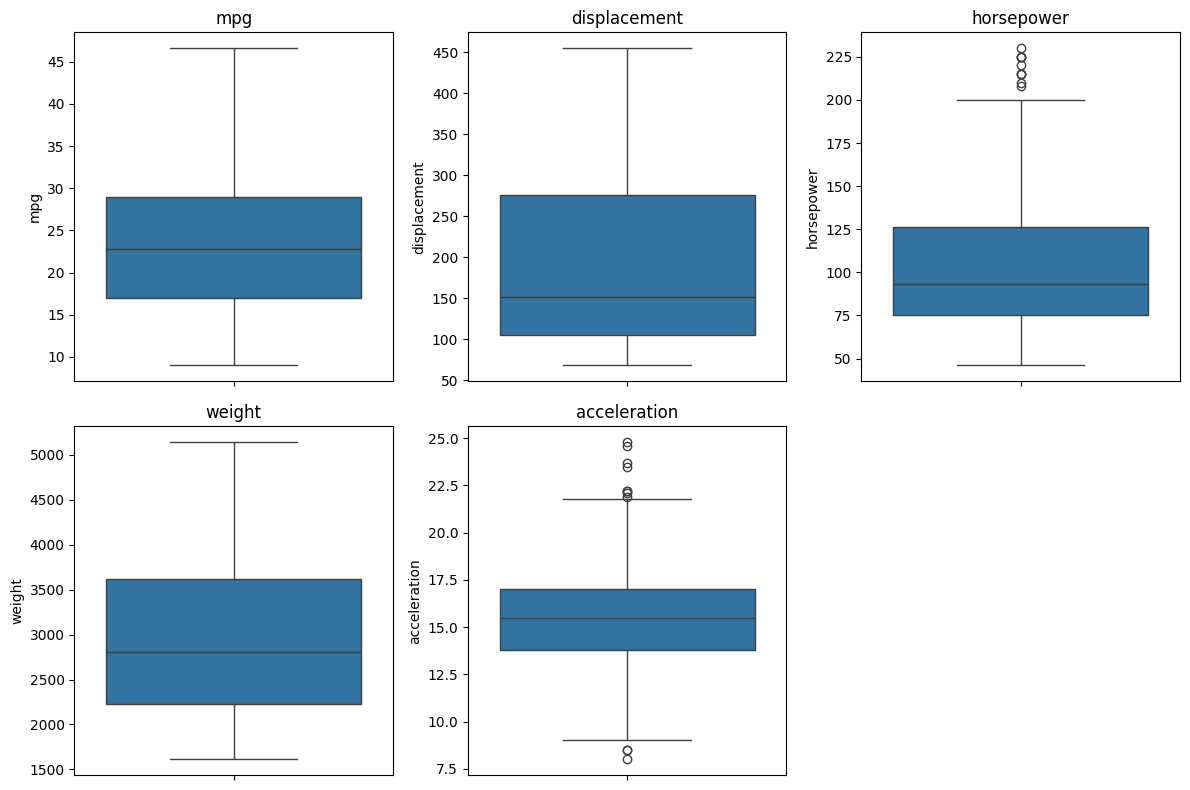

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=cars[col])
    plt.title(col)
plt.tight_layout()
plt.show()